# 화자 인식 — 전처리 v2 (시계열 시퀀스 기반)

**변경 이유**

기존 전처리는 MFCC를 평균/분산으로 압축해서 86차원 벡터로 만들었는데,
이러면 시간 순서 정보가 사라짐.

새 전처리는 시간 축을 살려서 LSTM이 프레임을 순서대로 읽을 수 있게
(41, T) 행렬로 저장함.
- 학습: 전체 발화로 한 번만
- 테스트: 저장된 시퀀스에서 윈도우만 잘라서 입력

**전처리 파이프라인**
```
WAV 로드
→ JSON SpeechStart~SpeechEnd 구간 추출
→ 유효성 검사
→ RMS 음량 정규화 (target_rms=0.1)
→ librosa.effects.trim (top_db=25)
→ VAD — 30ms 프레임 단위 비음성 제거
→ Pre-emphasis (coef=0.97)
→ MFCC(13) → CMN → Delta → Delta-Delta  →  (39, T)
→ Pitch(1, T) + Energy(1, T)
→ (41, T) 행렬로 저장
```

In [1]:
# 필요 패키지 설치
import subprocess
subprocess.run(["pip", "install", "webrtcvad", "-q"])


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


CompletedProcess(args=['pip', 'install', 'webrtcvad', '-q'], returncode=0)

In [2]:
# ── 임포트 & 설정 ──────────────────────────────────────────────
import os, json, struct, random, warnings
import numpy as np
import librosa
import webrtcvad
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path

matplotlib.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
warnings.filterwarnings("ignore")

# ── 경로 ──────────────────────────────────────────────────────
BASE       = "/Users/jinbaaaaang/Downloads/New_Sample"
LABEL_ROOT = os.path.join(BASE, "라벨링데이터", "TL_common_01")
WAV_ROOT   = os.path.join(BASE, "원천데이터",   "TS_common_01")
OUTPUT_DIR = os.path.join(BASE, "outputs", "sequences")

# ── 설정값 ────────────────────────────────────────────────────
SR              = 16000
HOP_LENGTH      = 160
N_MFCC          = 13
PRE_EMPHASIS    = 0.97
TARGET_RMS      = 0.1
TRIM_TOP_DB     = 25
MIN_TRIM_SEC    = 0.15
MAX_DURATION    = 30.0
MIN_VOICED      = 0.1
RANDOM_SEED     = 42
DPI             = 100

# VAD 설정
VAD_AGGRESSIVENESS = 2   # 0~3, 높을수록 공격적
VAD_FRAME_MS       = 30  # 프레임 길이 (ms)

# 테스트용 윈도우 — VAD 후 순수 발화 기준
WINDOW_SECS = [0.3, 0.5, 0.75, 1.0, 1.5, None]  # None = 전체 발화

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("설정 완료")
print(f"LABEL_ROOT : {LABEL_ROOT}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")

/Users/jinbaaaaang/Downloads/speaker_recognition/venv/lib/python3.13/site-packages/webrtcvad.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


설정 완료
LABEL_ROOT : /Users/jinbaaaaang/Downloads/New_Sample/라벨링데이터/TL_common_01
OUTPUT_DIR : /Users/jinbaaaaang/Downloads/New_Sample/outputs/sequences


## 파일 목록 수집

In [3]:
def get_file_pairs():
    """WAV + JSON 쌍을 수집해서 (wav_path, json_path, speaker_id) 리스트 반환"""
    pairs = []
    for date_folder in sorted(os.listdir(LABEL_ROOT)):
        label_date = os.path.join(LABEL_ROOT, date_folder)
        wav_date   = os.path.join(WAV_ROOT,   date_folder)
        if not os.path.isdir(label_date):
            continue
        for speaker_id in sorted(os.listdir(label_date)):
            label_spk = os.path.join(label_date, speaker_id)
            wav_spk   = os.path.join(wav_date,   speaker_id)
            if not os.path.isdir(label_spk):
                continue
            for jf in sorted(f for f in os.listdir(label_spk) if f.endswith(".json")):
                json_path = os.path.join(label_spk, jf)
                wav_path  = os.path.join(wav_spk, jf.replace(".json", ".wav"))
                if os.path.exists(wav_path):
                    pairs.append((wav_path, json_path, speaker_id))
    return pairs


def get_diverse_pairs(pairs, n=5):
    """서로 다른 화자 n명의 첫 번째 파일 반환"""
    seen, out = set(), []
    for p in pairs:
        if p[2] not in seen:
            out.append(p)
            seen.add(p[2])
        if len(out) >= n:
            break
    return out


pairs        = get_file_pairs()
diverse_pairs = get_diverse_pairs(pairs, 5)
wav_path, json_path, spk = pairs[0]

print(f"총 파일 수 : {len(pairs)}개")
print(f"샘플 파일  : {os.path.basename(wav_path)} (화자 {spk})")

총 파일 수 : 4835개
샘플 파일  : B0001-0047F1111-106001_0-00018869.wav (화자 0047)


## 헬퍼 함수

In [4]:
# ── 공통 헬퍼 ─────────────────────────────────────────────────

def _load_meta(json_path):
    """JSON에서 SpeechStart, SpeechEnd 읽기"""
    with open(json_path, encoding="utf-8") as f:
        meta = json.load(f)
    offset   = float(meta["Other"]["SpeechStart"])
    end_time = float(meta["Other"]["SpeechEnd"])
    duration = end_time - offset
    return offset, duration


def _validate_segment(offset, duration):
    """발화 구간 유효성 검사"""
    if duration <= 0 or duration > MAX_DURATION:
        return None, None
    if offset < 0:
        offset = 0.0
    return offset, duration


def _rms_normalize(y):
    """RMS 기반 음량 정규화"""
    rms = float(np.sqrt(np.mean(y ** 2)))
    if rms > 1e-6:
        y = y * (TARGET_RMS / rms)
    y = np.clip(y, -1.0, 1.0)
    return y, rms


def _pre_emphasis(y, coef=PRE_EMPHASIS):
    """Pre-emphasis 필터 — 고주파 강조"""
    return np.append(y[0], y[1:] - coef * y[:-1])


def _apply_vad(y, sr=SR, aggressiveness=VAD_AGGRESSIVENESS, frame_ms=VAD_FRAME_MS):
    """
    webrtcvad로 비음성 프레임 제거 후 순수 발화만 반환.
    음성 프레임만 이어붙여서 반환.
    결과가 비어있으면 원본 y 반환 (안전장치).
    """
    vad       = webrtcvad.Vad(aggressiveness)
    frame_len = int(sr * frame_ms / 1000)  # 프레임당 샘플 수

    # float32 → int16 PCM 변환
    y_int16 = np.clip(y, -1.0, 1.0)
    y_int16 = (y_int16 * 32767).astype(np.int16)

    voiced_frames = []
    for start in range(0, len(y_int16) - frame_len + 1, frame_len):
        frame = y_int16[start:start + frame_len]
        raw   = struct.pack(f"{len(frame)}h", *frame)
        if vad.is_speech(raw, sr):
            # int16 → float32로 다시 변환해서 저장
            voiced_frames.append(y[start:start + frame_len])

    if not voiced_frames:
        return y  # 음성 프레임이 없으면 원본 반환

    return np.concatenate(voiced_frames)


def _mfcc_pipeline_seq(y):
    """
    MFCC를 압축하지 않고 프레임 시퀀스로 반환.
    반환: (39, T) — MFCC(13) + Delta(13) + Delta-Delta(13)
    CMN 적용 후 Delta 계산.
    """
    mfcc_raw = librosa.feature.mfcc(
        y=y, sr=SR, n_mfcc=N_MFCC, hop_length=HOP_LENGTH
    )
    # CMN: 프레임 평균 차감 (채널 효과 제거)
    mfcc_cmn = mfcc_raw - mfcc_raw.mean(axis=1, keepdims=True)
    delta    = librosa.feature.delta(mfcc_cmn)
    delta2   = librosa.feature.delta(mfcc_cmn, order=2)
    return mfcc_raw, mfcc_cmn, delta, delta2, np.concatenate([mfcc_cmn, delta, delta2], axis=0)


def _pitch_energy_seq(y, n_frames):
    """
    Pitch와 Energy를 프레임 단위로 반환.
    반환: (2, T) — pitch(1, T) + energy(1, T)
    프레임 수를 n_frames에 맞게 정렬.
    유성음 비율 0.1 미만이면 None 반환.
    """
    pitch  = librosa.yin(y, fmin=50, fmax=400, hop_length=HOP_LENGTH)
    energy = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)[0]

    # 유성음 비율 검사
    voiced_ratio = float((pitch > 0).mean())
    if voiced_ratio < MIN_VOICED:
        return None, None, voiced_ratio

    # 프레임 수를 n_frames에 맞게 정렬 (앞에서 자르거나 패딩)
    def _align(arr, n):
        if len(arr) >= n:
            return arr[:n]
        return np.pad(arr, (0, n - len(arr)))

    pitch_aligned  = _align(pitch,  n_frames).reshape(1, -1)
    energy_aligned = _align(energy, n_frames).reshape(1, -1)

    return pitch_aligned, energy_aligned, voiced_ratio


print("헬퍼 함수 정의 완료")

헬퍼 함수 정의 완료


## 메인 추출 함수

In [5]:
def extract_sequence(wav_path, json_path):
    """
    전체 발화를 (41, T) 행렬로 반환. 학습용.
    41 = MFCC+Delta+Delta-Delta(39) + Pitch(1) + Energy(1)
    실패 시 None 반환.

    파이프라인:
    WAV 로드 → 유효성 검사 → RMS 정규화 → trim
    → VAD → Pre-emphasis → MFCC(CMN)+Delta+ΔΔ → Pitch+Energy
    → (41, T) 반환
    """
    try:
        # 1. 메타데이터 로드 & 유효성 검사
        offset, duration = _load_meta(json_path)
        offset, duration = _validate_segment(offset, duration)
        if offset is None:
            return None

        # 2. 발화 구간 로드
        y, _ = librosa.load(wav_path, sr=SR, offset=offset, duration=duration)

        # 3. RMS 음량 정규화
        y, _ = _rms_normalize(y)

        # 4. 에너지 기반 재트리밍
        y, _ = librosa.effects.trim(y, top_db=TRIM_TOP_DB, frame_length=512, hop_length=128)
        if len(y) / SR < MIN_TRIM_SEC:
            return None

        # 5. VAD — 비음성 프레임 제거
        y = _apply_vad(y)
        if len(y) / SR < MIN_TRIM_SEC:
            return None

        # 6. Pre-emphasis
        y = _pre_emphasis(y)

        # 7. MFCC + CMN + Delta + Delta-Delta → (39, T)
        _, _, _, _, mfcc_seq = _mfcc_pipeline_seq(y)
        n_frames = mfcc_seq.shape[1]

        # 8. Pitch + Energy → (2, T)
        pitch_seq, energy_seq, voiced_ratio = _pitch_energy_seq(y, n_frames)
        if pitch_seq is None:
            return None

        # 9. 이어붙이기 → (41, T)
        feature_seq = np.concatenate([mfcc_seq, pitch_seq, energy_seq], axis=0)
        return feature_seq.astype(np.float32)

    except Exception as e:
        print(f"  스킵: {os.path.basename(wav_path)} ({e})")
        return None


def slice_window(feature_seq, window_sec):
    """
    (41, T) 행렬에서 앞 window_sec초치 프레임만 잘라서 반환.
    window_sec=None이면 전체 반환.
    발화가 윈도우보다 짧으면 None 반환.
    """
    if window_sec is None:
        return feature_seq
    n_frames = int(window_sec * SR / HOP_LENGTH)
    if feature_seq.shape[1] < n_frames:
        return None
    return feature_seq[:, :n_frames]


def load_and_slice(npy_path, window_sec):
    """
    저장된 (41, T) npy 파일을 로드하고 window_sec초치만 잘라서 반환.
    LSTM 입력 형태 (T, 41)로 변환해서 반환.
    """
    feat = np.load(npy_path)              # (41, T)
    feat = slice_window(feat, window_sec) # (41, T_window)
    if feat is None:
        return None
    return feat.T                          # (T, 41) — LSTM 입력 형태


# 동작 확인
feat_test = extract_sequence(wav_path, json_path)
if feat_test is not None:
    print(f"extract_sequence shape : {feat_test.shape}  (41 x T)")
    print(f"발화 길이              : {feat_test.shape[1] * HOP_LENGTH / SR:.2f}초")
    for w in WINDOW_SECS:
        sliced = slice_window(feat_test, w)
        label  = f"{w}초" if w else "전체"
        shape  = sliced.shape if sliced is not None else "스킵"
        print(f"  window={label:>5} → {shape}")
else:
    print("샘플 추출 실패")

extract_sequence shape : (41, 214)  (41 x T)
발화 길이              : 2.14초
  window= 0.3초 → (41, 30)
  window= 0.5초 → (41, 50)
  window=0.75초 → (41, 75)
  window= 1.0초 → (41, 100)
  window= 1.5초 → (41, 150)
  window=   전체 → (41, 214)


## 시각화 — 전처리 단계별 신호 변화

In [6]:
# 시각화용 중간 단계 결과를 dict로 반환하는 함수
def extract_with_viz(wav_path, json_path):
    """각 전처리 단계의 중간 결과를 dict로 반환 (시각화용)"""
    try:
        offset, duration = _load_meta(json_path)
        offset, duration = _validate_segment(offset, duration)
        if offset is None:
            return None

        # 단계별 중간 결과 저장
        y_full, _ = librosa.load(wav_path, sr=SR)
        y_seg,  _ = librosa.load(wav_path, sr=SR, offset=offset, duration=duration)

        y_norm, rms_before = _rms_normalize(y_seg.copy())

        y_trim, idx = librosa.effects.trim(
            y_norm, top_db=TRIM_TOP_DB, frame_length=512, hop_length=128
        )
        if len(y_trim) / SR < MIN_TRIM_SEC:
            return None

        y_vad   = _apply_vad(y_trim.copy())
        y_pre   = _pre_emphasis(y_vad.copy())

        mfcc_raw, mfcc_cmn, delta, delta2, mfcc_seq = _mfcc_pipeline_seq(y_pre)
        n_frames = mfcc_seq.shape[1]
        pitch_seq, energy_seq, voiced_ratio = _pitch_energy_seq(y_pre, n_frames)
        if pitch_seq is None:
            return None

        feature_seq = np.concatenate([mfcc_seq, pitch_seq, energy_seq], axis=0)

        # Pitch/Energy 1D 시각화용
        pitch_1d  = librosa.yin(y_pre, fmin=50, fmax=400, hop_length=HOP_LENGTH)
        energy_1d = librosa.feature.rms(y=y_pre, hop_length=HOP_LENGTH)[0]

        return {
            "offset"       : offset,
            "duration"     : duration,
            "y_full"       : y_full,
            "y_seg"        : y_seg,
            "y_norm"       : y_norm,
            "rms_before"   : rms_before,
            "y_trim"       : y_trim,
            "trim_idx"     : idx,
            "y_vad"        : y_vad,
            "y_pre"        : y_pre,
            "mfcc_raw"     : mfcc_raw,
            "mfcc_cmn"     : mfcc_cmn,
            "delta"        : delta,
            "delta2"       : delta2,
            "pitch_1d"     : pitch_1d,
            "energy_1d"    : energy_1d,
            "feature_seq"  : feature_seq,
            "voiced_ratio" : voiced_ratio,
        }
    except Exception as e:
        print(f"viz 추출 실패: {e}")
        return None


def time_axis(y, sr=SR):
    return np.arange(len(y)) / sr


viz = extract_with_viz(wav_path, json_path)
print("시각화 데이터 준비 완료" if viz else "시각화 데이터 준비 실패")

시각화 데이터 준비 완료


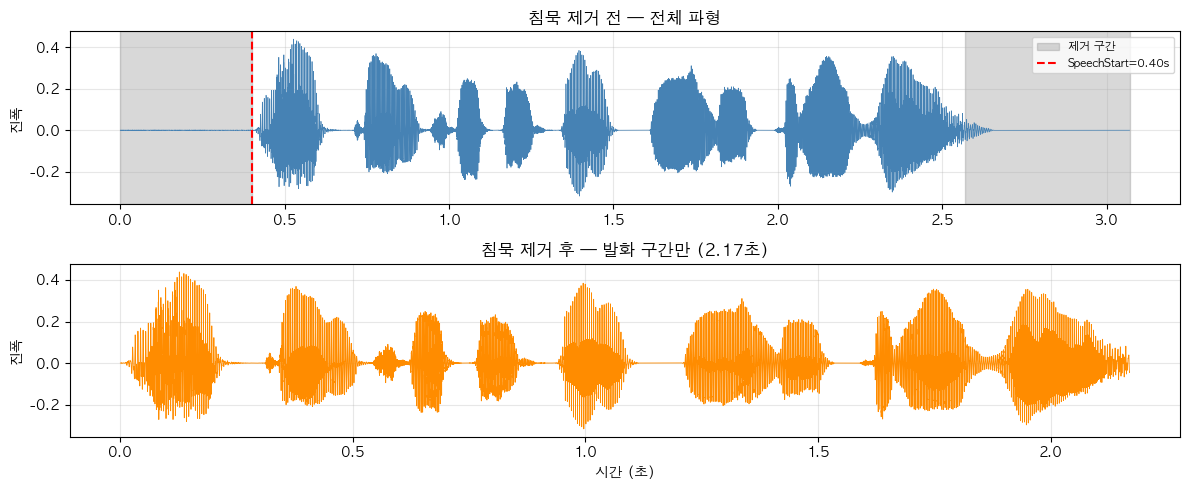

In [7]:
# 시각화 0-1: 원본 vs 침묵 제거
offset     = viz["offset"]
duration   = viz["duration"]
y_full     = viz["y_full"]
y_seg      = viz["y_seg"]
t_full     = time_axis(y_full)
t_seg      = time_axis(y_seg)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), dpi=DPI)

axes[0].plot(t_full, y_full, color="steelblue", linewidth=0.5)
axes[0].axvspan(0, offset, color="gray", alpha=0.3, label="제거 구간")
if offset + duration < t_full[-1]:
    axes[0].axvspan(offset + duration, t_full[-1], color="gray", alpha=0.3)
axes[0].axvline(offset, color="red", linewidth=1.5, linestyle="--", label=f"SpeechStart={offset:.2f}s")
axes[0].set_title("침묵 제거 전 — 전체 파형")
axes[0].set_ylabel("진폭")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(t_seg, y_seg, color="darkorange", linewidth=0.6)
axes[1].set_title(f"침묵 제거 후 — 발화 구간만 ({duration:.2f}초)")
axes[1].set_xlabel("시간 (초)")
axes[1].set_ylabel("진폭")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

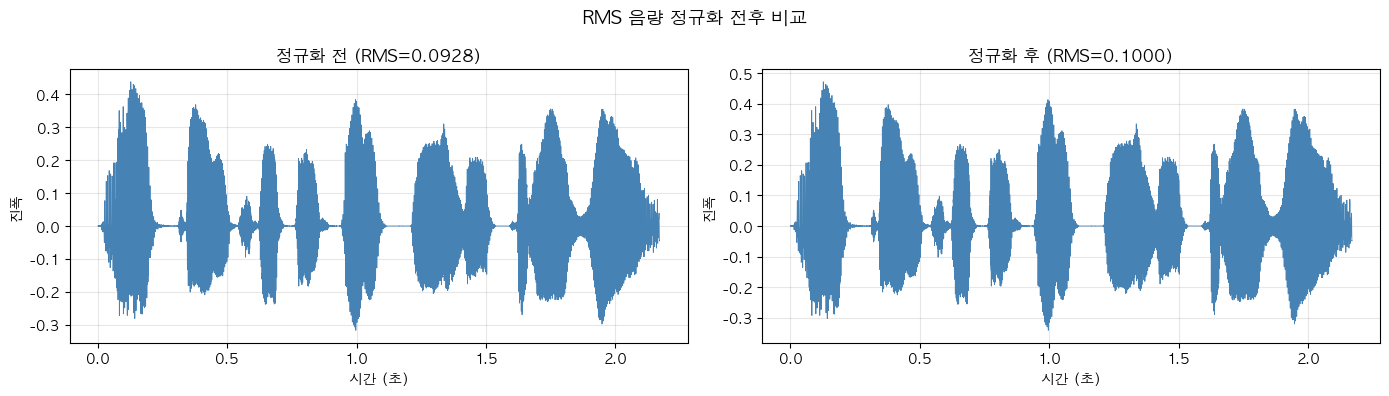

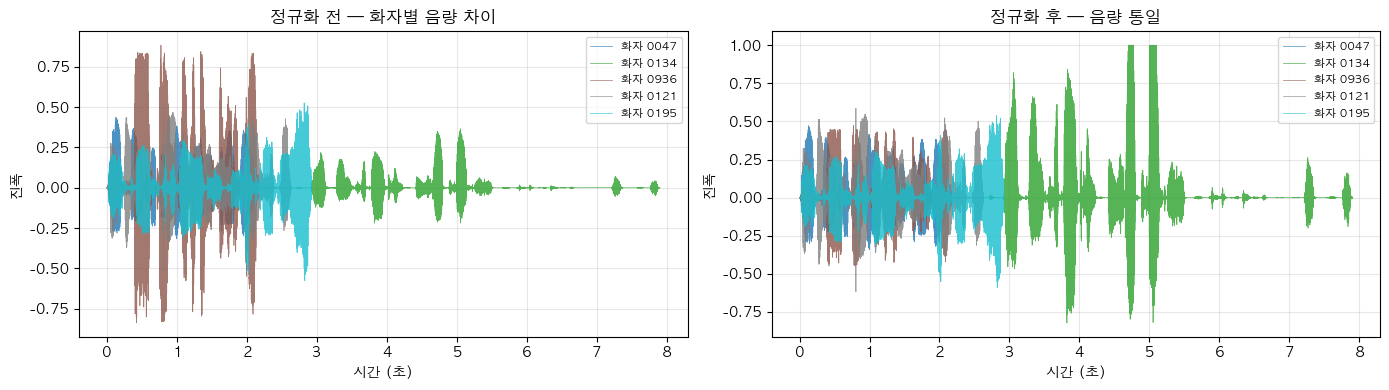

In [8]:
# 시각화 0-2: 음량 정규화 전후
y_seg_raw  = viz["y_seg"]
y_norm     = viz["y_norm"]
rms_before = viz["rms_before"]
colors_spk = plt.cm.tab10(np.linspace(0, 1, len(diverse_pairs)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=DPI)

# 단일 파일 전/후
for ax, y, title in [
    (axes[0], y_seg_raw, f"정규화 전 (RMS={rms_before:.4f})"),
    (axes[1], y_norm,    f"정규화 후 (RMS={TARGET_RMS:.4f})"),
]:
    ax.plot(time_axis(y), y, color="steelblue", linewidth=0.6)
    ax.set_title(title)
    ax.set_xlabel("시간 (초)")
    ax.set_ylabel("진폭")
    ax.grid(alpha=0.3)

plt.suptitle("RMS 음량 정규화 전후 비교", fontsize=13)
plt.tight_layout()
plt.show()

# 화자 5명 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=DPI)

for ax_idx, normalize in enumerate([False, True]):
    ax = axes[ax_idx]
    for i, (wp, jp, sid) in enumerate(diverse_pairs):
        v = extract_with_viz(wp, jp)
        if v is None:
            continue
        yp = v["y_seg"].copy()
        if normalize:
            yp, _ = _rms_normalize(yp)
        ax.plot(time_axis(yp), yp, linewidth=0.5, alpha=0.8,
                color=colors_spk[i], label=f"화자 {sid}")
    ax.set_title("정규화 후 — 음량 통일" if normalize else "정규화 전 — 화자별 음량 차이")
    ax.set_xlabel("시간 (초)")
    ax.set_ylabel("진폭")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

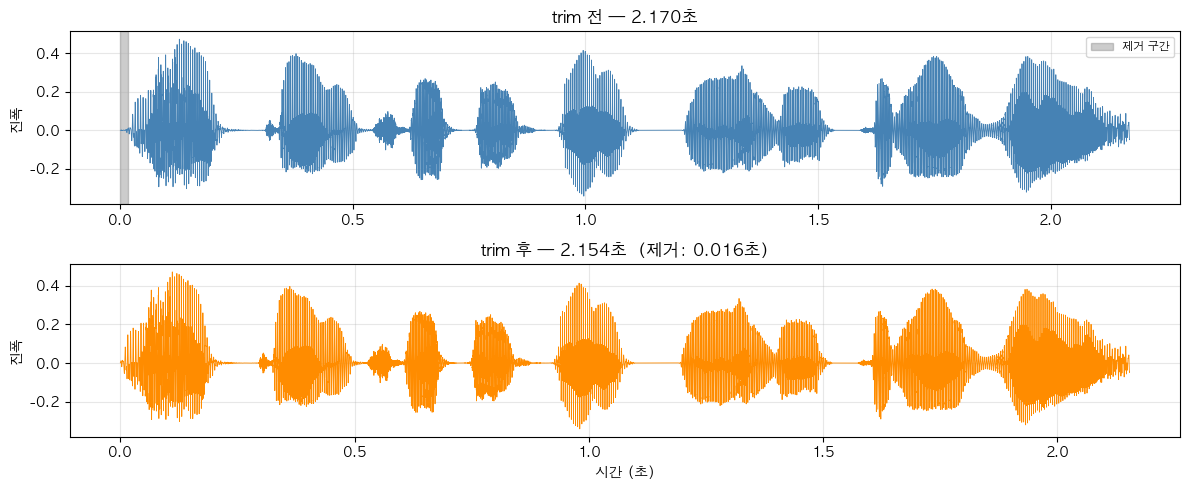

In [9]:
# 시각화 0-3: librosa trim 전후
y_norm  = viz["y_norm"]
y_trim  = viz["y_trim"]
idx     = viz["trim_idx"]
t_norm  = time_axis(y_norm)

fig, axes = plt.subplots(2, 1, figsize=(12, 5), dpi=DPI)

axes[0].plot(t_norm, y_norm, color="steelblue", linewidth=0.6)
if idx[0] > 0:
    axes[0].axvspan(0, idx[0] / SR, color="gray", alpha=0.4, label="제거 구간")
if idx[1] < len(y_norm):
    axes[0].axvspan(idx[1] / SR, t_norm[-1], color="gray", alpha=0.4)
axes[0].set_title(f"trim 전 — {len(y_norm)/SR:.3f}초")
axes[0].set_ylabel("진폭")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(time_axis(y_trim), y_trim, color="darkorange", linewidth=0.6)
axes[1].set_title(f"trim 후 — {len(y_trim)/SR:.3f}초  (제거: {(len(y_norm)-len(y_trim))/SR:.3f}초)")
axes[1].set_xlabel("시간 (초)")
axes[1].set_ylabel("진폭")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

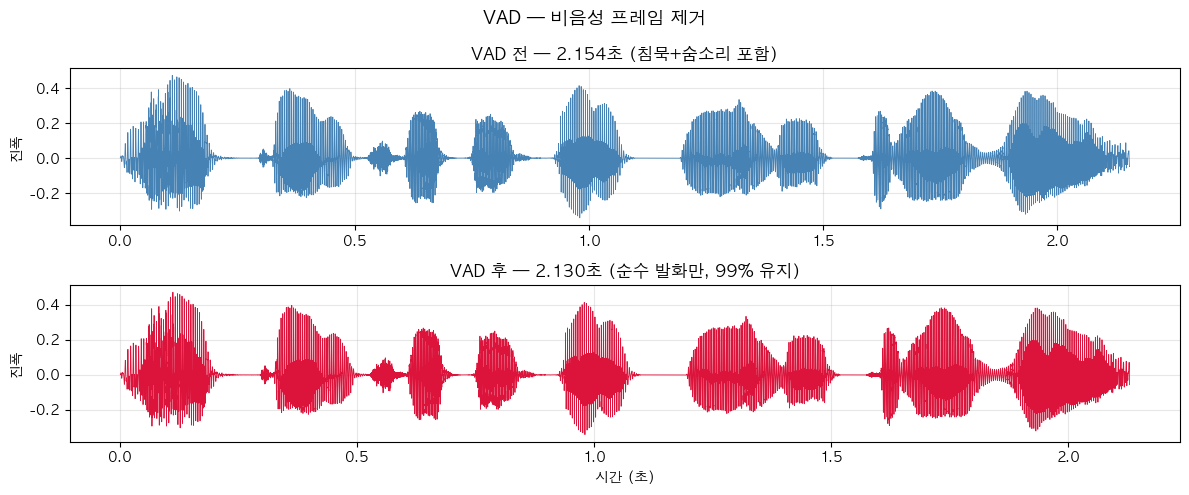

In [10]:
# 시각화 0-4: VAD 전후
y_trim  = viz["y_trim"]
y_vad   = viz["y_vad"]

vad_ratio = len(y_vad) / len(y_trim) * 100

fig, axes = plt.subplots(2, 1, figsize=(12, 5), dpi=DPI)

axes[0].plot(time_axis(y_trim), y_trim, color="steelblue", linewidth=0.6)
axes[0].set_title(f"VAD 전 — {len(y_trim)/SR:.3f}초 (침묵+숨소리 포함)")
axes[0].set_ylabel("진폭")
axes[0].grid(alpha=0.3)

axes[1].plot(time_axis(y_vad), y_vad, color="crimson", linewidth=0.6)
axes[1].set_title(f"VAD 후 — {len(y_vad)/SR:.3f}초 (순수 발화만, {vad_ratio:.0f}% 유지)")
axes[1].set_xlabel("시간 (초)")
axes[1].set_ylabel("진폭")
axes[1].grid(alpha=0.3)

plt.suptitle("VAD — 비음성 프레임 제거", fontsize=13)
plt.tight_layout()
plt.show()

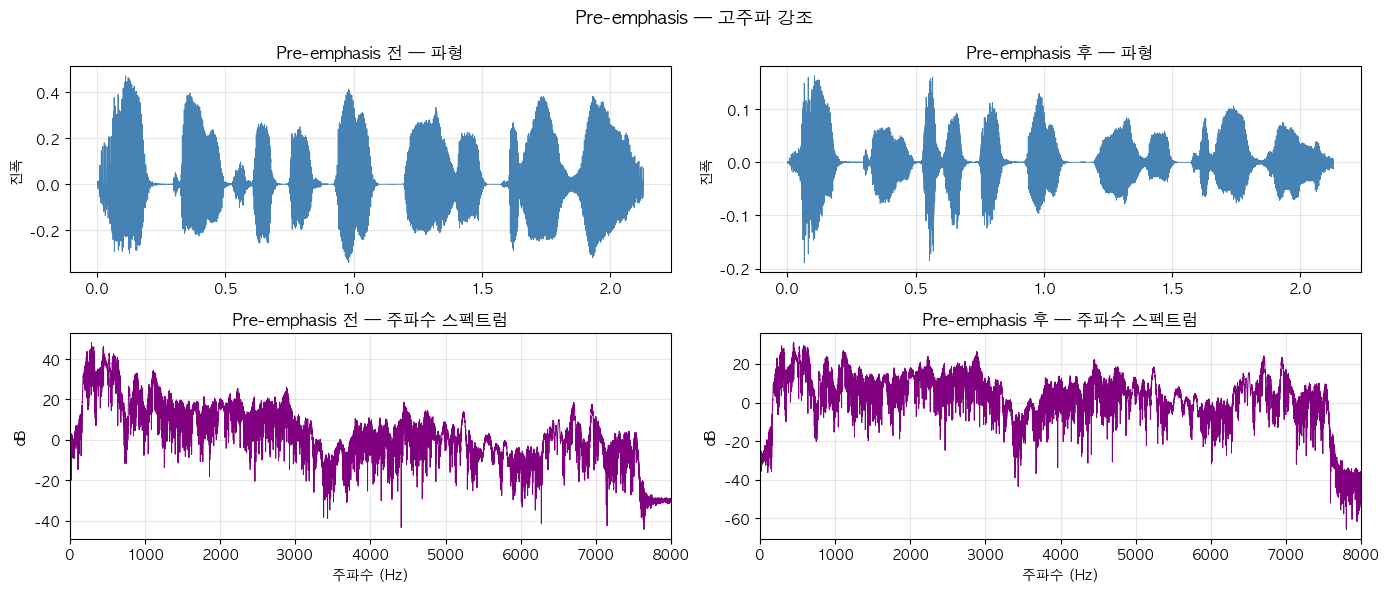

In [11]:
# 시각화 0-5: Pre-emphasis 전후 (파형 + 스펙트럼)
y_before = viz["y_vad"]
y_after  = viz["y_pre"]

def spectrum_db(y, sr=SR):
    freqs  = np.fft.rfftfreq(len(y), 1 / sr)
    mag_db = 20 * np.log10(np.abs(np.fft.rfft(y)) + 1e-10)
    return freqs, mag_db

fig, axes = plt.subplots(2, 2, figsize=(14, 6), dpi=DPI)

for col, (y, label) in enumerate([(y_before, "Pre-emphasis 전"), (y_after, "Pre-emphasis 후")]):
    axes[0, col].plot(time_axis(y), y, linewidth=0.6, color="steelblue")
    axes[0, col].set_title(f"{label} — 파형")
    axes[0, col].set_ylabel("진폭")
    axes[0, col].grid(alpha=0.3)

    freqs, mag_db = spectrum_db(y)
    axes[1, col].plot(freqs, mag_db, linewidth=0.7, color="purple")
    axes[1, col].set_xlim(0, 8000)
    axes[1, col].set_title(f"{label} — 주파수 스펙트럼")
    axes[1, col].set_xlabel("주파수 (Hz)")
    axes[1, col].set_ylabel("dB")
    axes[1, col].grid(alpha=0.3)

plt.suptitle("Pre-emphasis — 고주파 강조", fontsize=13)
plt.tight_layout()
plt.show()

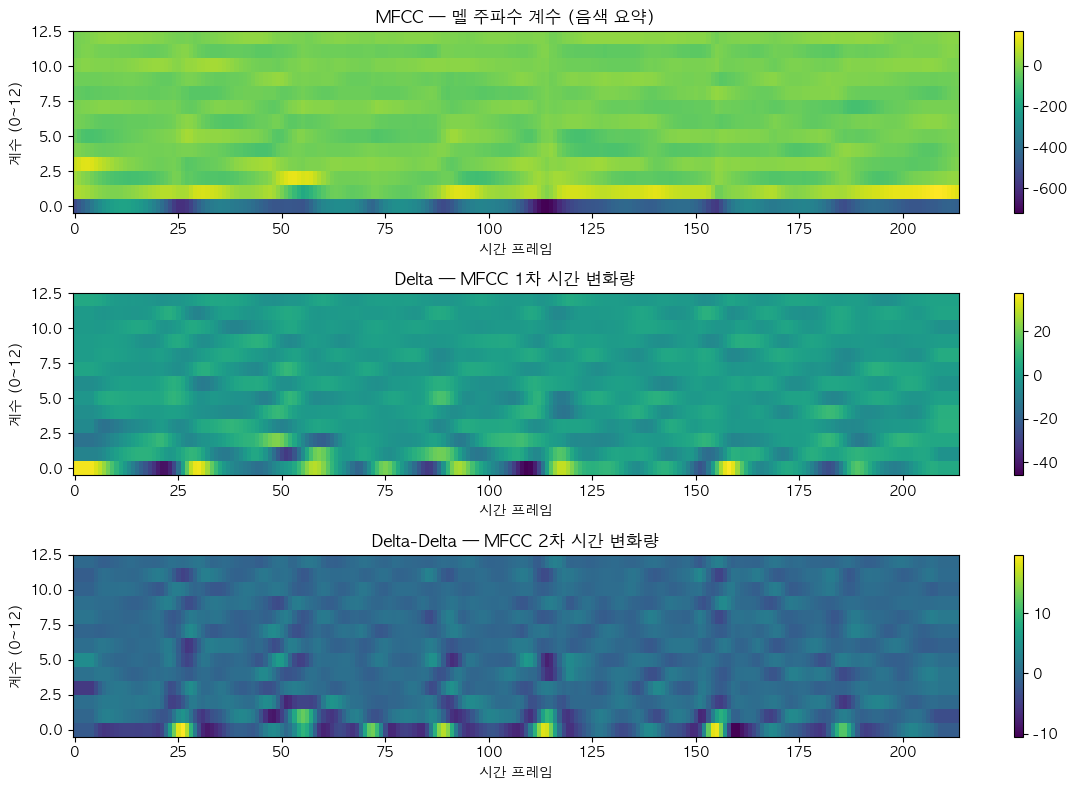

In [12]:
# 시각화 0-6: MFCC + Delta + Delta-Delta heatmap
mfcc_raw = viz["mfcc_raw"]
delta    = viz["delta"]
delta2   = viz["delta2"]

fig, axes = plt.subplots(3, 1, figsize=(12, 8), dpi=DPI)

for ax, data, title in [
    (axes[0], mfcc_raw, "MFCC — 멜 주파수 계수 (음색 요약)"),
    (axes[1], delta,    "Delta — MFCC 1차 시간 변화량"),
    (axes[2], delta2,   "Delta-Delta — MFCC 2차 시간 변화량"),
]:
    im = ax.imshow(data, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(title)
    ax.set_ylabel("계수 (0~12)")
    ax.set_xlabel("시간 프레임")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

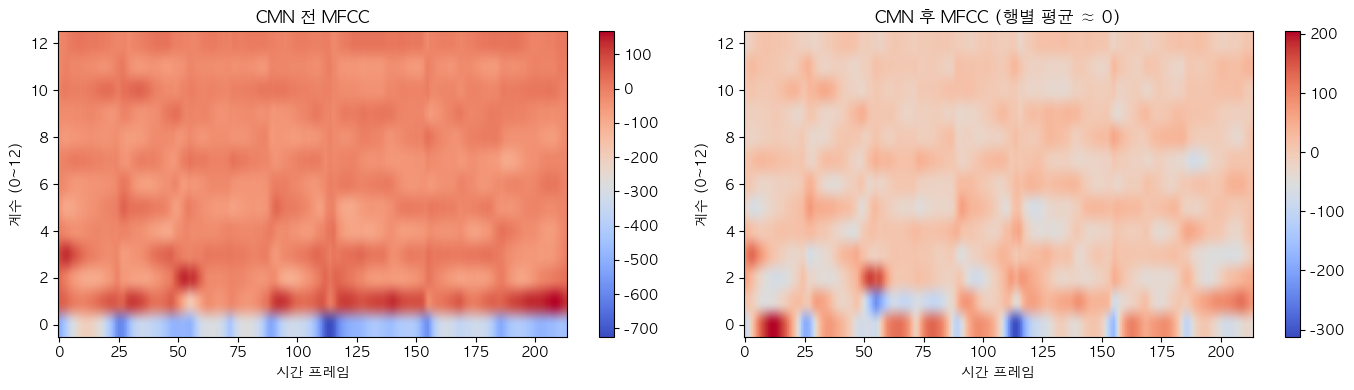

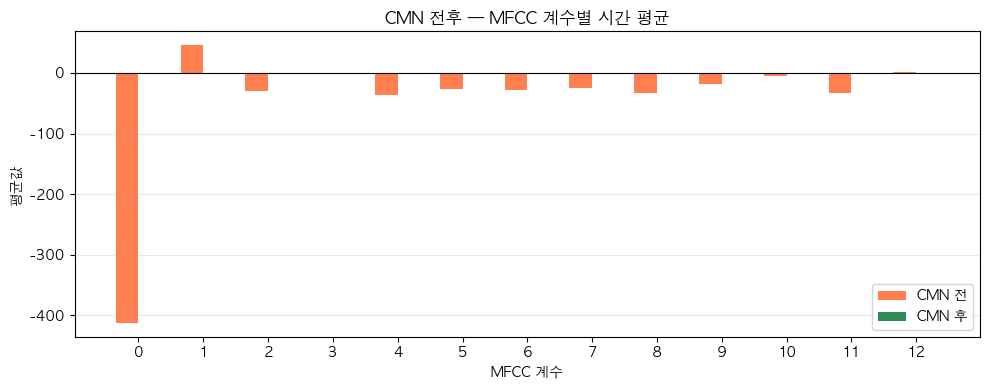

In [13]:
# 시각화 0-7: CMN 전후
mfcc_raw = viz["mfcc_raw"]
mfcc_cmn = viz["mfcc_cmn"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), dpi=DPI)
for ax, data, title in [
    (axes[0], mfcc_raw, "CMN 전 MFCC"),
    (axes[1], mfcc_cmn, "CMN 후 MFCC (행별 평균 ≈ 0)"),
]:
    im = ax.imshow(data, aspect="auto", origin="lower", cmap="coolwarm")
    ax.set_title(title)
    ax.set_ylabel("계수 (0~12)")
    ax.set_xlabel("시간 프레임")
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# 계수별 평균 막대그래프
coef_idx = np.arange(N_MFCC)
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4), dpi=DPI)
ax.bar(coef_idx - w/2, mfcc_raw.mean(axis=1), width=w, label="CMN 전", color="coral")
ax.bar(coef_idx + w/2, mfcc_cmn.mean(axis=1), width=w, label="CMN 후", color="seagreen")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("CMN 전후 — MFCC 계수별 시간 평균")
ax.set_xlabel("MFCC 계수")
ax.set_ylabel("평균값")
ax.set_xticks(coef_idx)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

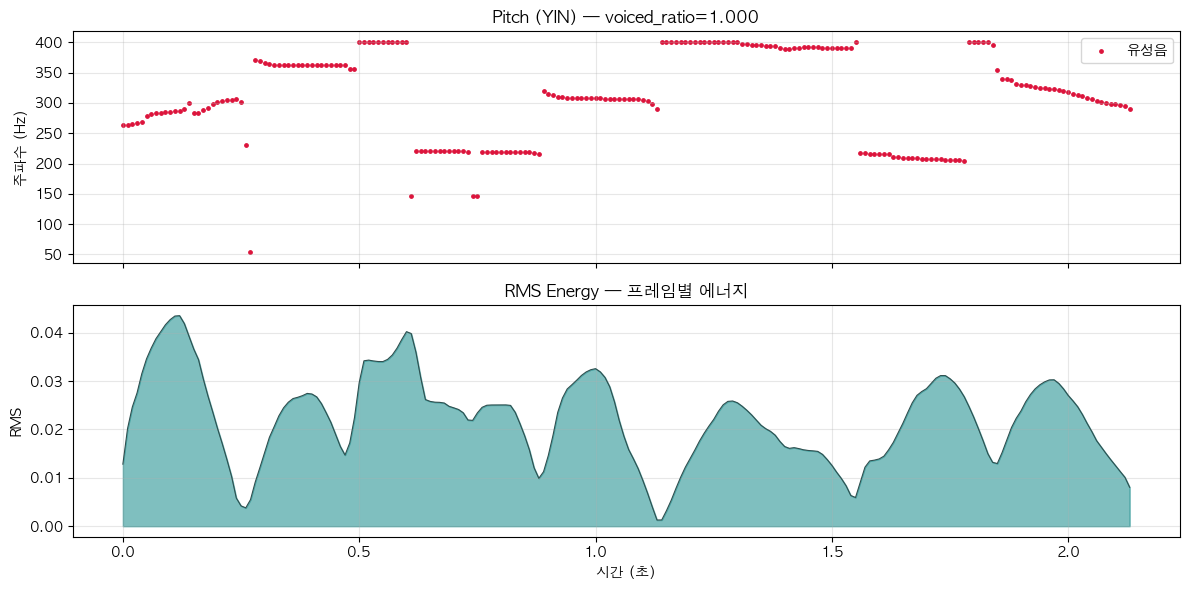

In [14]:
# 시각화 0-8: Pitch + Energy 프레임 시퀀스
pitch_1d  = viz["pitch_1d"]
energy_1d = viz["energy_1d"]
voiced    = pitch_1d > 0
t_frames  = librosa.frames_to_time(np.arange(len(pitch_1d)), sr=SR, hop_length=HOP_LENGTH)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), dpi=DPI, sharex=True)

# Pitch
for i in range(len(t_frames) - 1):
    if not voiced[i]:
        axes[0].axvspan(t_frames[i], t_frames[i+1], color="lightgray", alpha=0.3)
axes[0].scatter(t_frames[voiced], pitch_1d[voiced], s=6, c="crimson", label="유성음")
axes[0].set_title(f"Pitch (YIN) — voiced_ratio={viz['voiced_ratio']:.3f}")
axes[0].set_ylabel("주파수 (Hz)")
axes[0].legend()
axes[0].grid(alpha=0.3)

# RMS Energy
t_energy = librosa.frames_to_time(np.arange(len(energy_1d)), sr=SR, hop_length=HOP_LENGTH)
axes[1].fill_between(t_energy, energy_1d, alpha=0.5, color="teal")
axes[1].plot(t_energy, energy_1d, color="darkslategray", linewidth=0.8)
axes[1].set_title("RMS Energy — 프레임별 에너지")
axes[1].set_xlabel("시간 (초)")
axes[1].set_ylabel("RMS")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

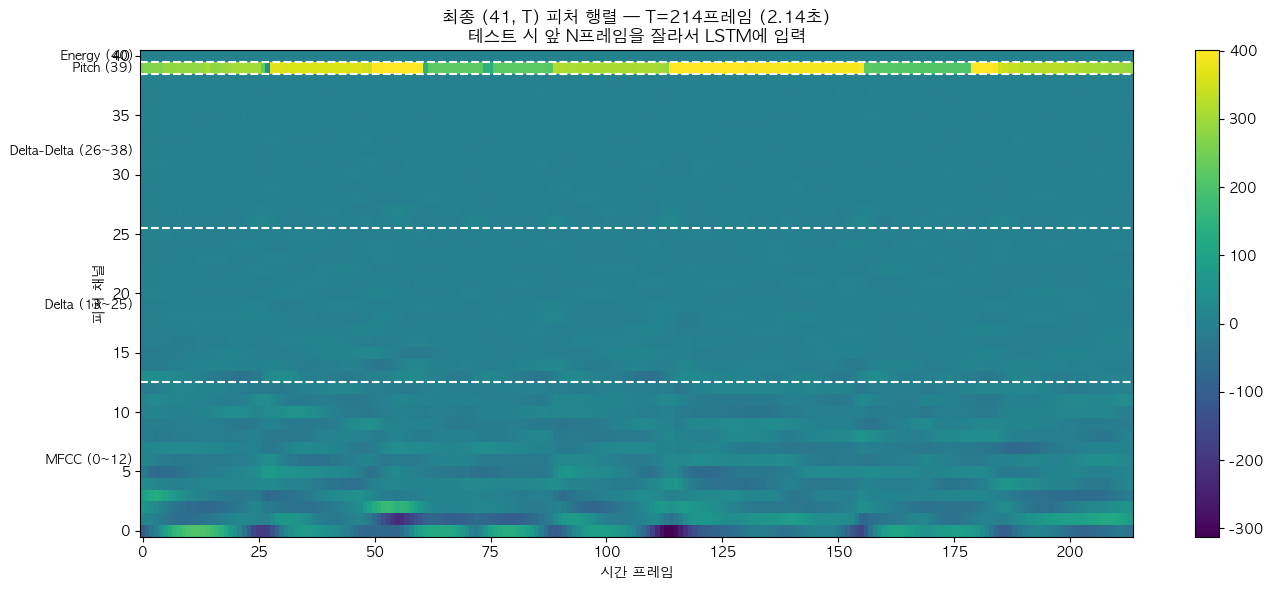

In [15]:
# 시각화 0-9: 최종 (41, T) 피처 행렬
feature_seq = viz["feature_seq"]

fig, ax = plt.subplots(figsize=(14, 6), dpi=DPI)
im = ax.imshow(feature_seq, aspect="auto", origin="lower", cmap="viridis")

# 구간별 구분선
boundaries = [13, 26, 39, 40]
labels     = ["MFCC (0~12)", "Delta (13~25)", "Delta-Delta (26~38)", "Pitch (39)", "Energy (40)"]
for b in boundaries:
    ax.axhline(b - 0.5, color="white", linewidth=1.5, linestyle="--")

# 구간 레이블
centers = [6, 19, 32, 39, 40]
for c, lbl in zip(centers, labels):
    ax.text(-2, c, lbl, va="center", ha="right", fontsize=9, color="black")

ax.set_title(
    f"최종 (41, T) 피처 행렬 — "
    f"T={feature_seq.shape[1]}프레임 ({feature_seq.shape[1]*HOP_LENGTH/SR:.2f}초)\n"
    "테스트 시 앞 N프레임을 잘라서 LSTM에 입력"
)
ax.set_xlabel("시간 프레임")
ax.set_ylabel("피처 채널")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 시각화 — 윈도우별 슬라이싱

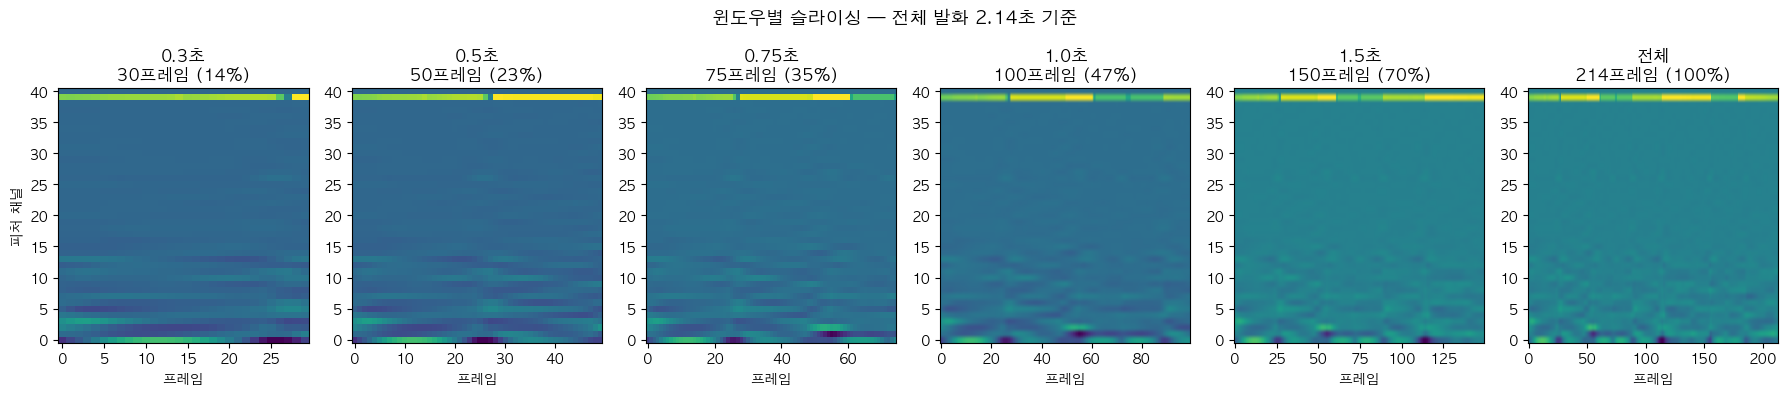

In [16]:
# 시각화 1: 윈도우별 슬라이싱 결과
feature_seq  = viz["feature_seq"]
total_frames = feature_seq.shape[1]
total_sec    = total_frames * HOP_LENGTH / SR

fig, axes = plt.subplots(1, len(WINDOW_SECS), figsize=(18, 4), dpi=DPI)

for ax, w in zip(axes, WINDOW_SECS):
    sliced = slice_window(feature_seq, w)
    label  = f"{w}초" if w else "전체"
    if sliced is None:
        ax.text(0.5, 0.5, "발화\n너무 짧음", ha="center", va="center",
                transform=ax.transAxes, fontsize=10)
        ax.set_title(f"{label}\n(스킵)")
        continue
    n_frames_w = sliced.shape[1]
    ratio      = n_frames_w / total_frames * 100
    ax.imshow(sliced, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(f"{label}\n{n_frames_w}프레임 ({ratio:.0f}%)")
    ax.set_xlabel("프레임")
    if ax == axes[0]:
        ax.set_ylabel("피처 채널")

plt.suptitle(f"윈도우별 슬라이싱 — 전체 발화 {total_sec:.2f}초 기준", fontsize=13)
plt.tight_layout()
plt.show()

## 시각화 — 발화 길이 분포

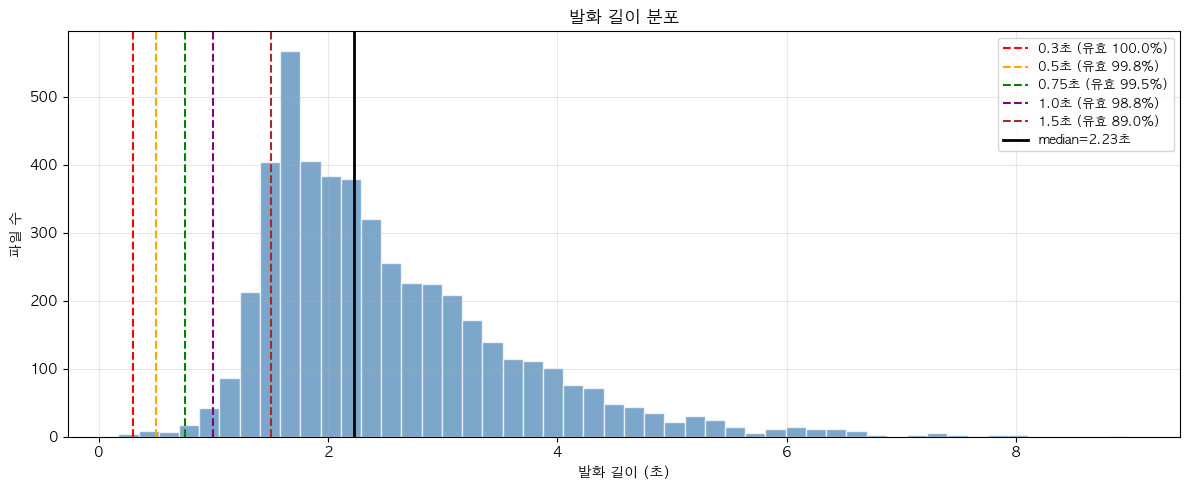

10th percentile: 1.47초
25th percentile: 1.71초
50th percentile: 2.23초
75th percentile: 3.06초
90th percentile: 3.99초


In [17]:
# 시각화 2: 발화 길이 분포 히스토그램
durations = []
for wp, jp, s in pairs:
    with open(jp, encoding="utf-8") as f:
        meta = json.load(f)
    d = float(meta["Other"]["SpeechEnd"]) - float(meta["Other"]["SpeechStart"])
    durations.append(d)
durations = np.array(durations)

fig, ax = plt.subplots(figsize=(12, 5), dpi=DPI)
ax.hist(durations, bins=50, color="steelblue", alpha=0.7, edgecolor="white")

colors_w = ["red", "orange", "green", "purple", "brown"]
for w, c in zip([w for w in WINDOW_SECS if w], colors_w):
    valid_ratio = (durations >= w).mean() * 100
    ax.axvline(w, color=c, linewidth=1.5, linestyle="--",
               label=f"{w}초 (유효 {valid_ratio:.1f}%)")

ax.axvline(np.median(durations), color="black", linewidth=2,
           label=f"median={np.median(durations):.2f}초")

ax.set_title("발화 길이 분포")
ax.set_xlabel("발화 길이 (초)")
ax.set_ylabel("파일 수")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for p in [10, 25, 50, 75, 90]:
    print(f"{p}th percentile: {np.percentile(durations, p):.2f}초")

## 시각화 — 화자별 피처 분포

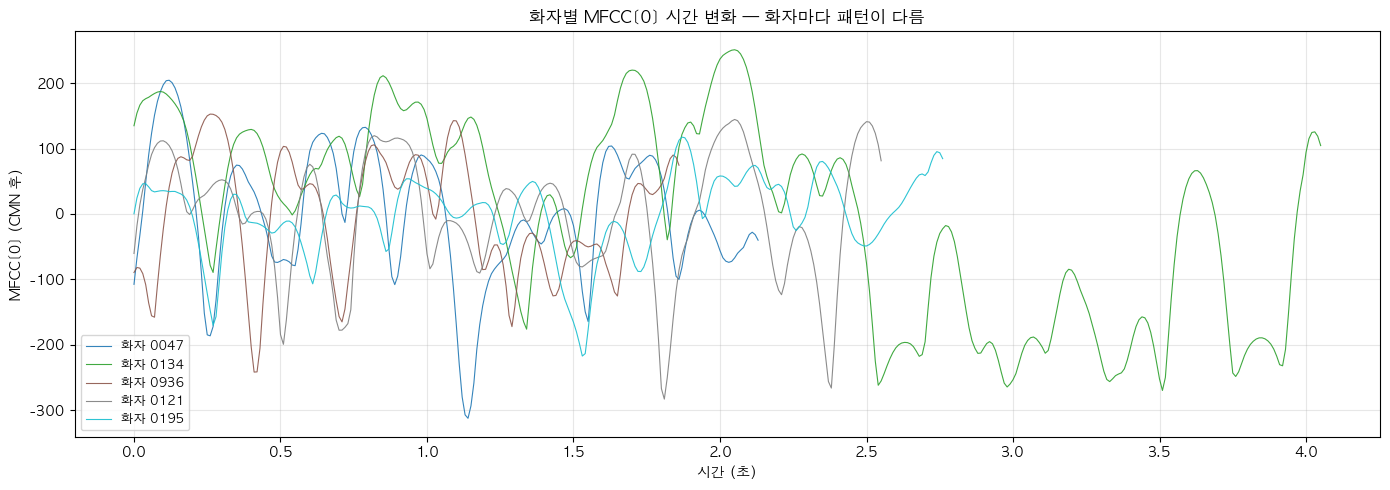

In [18]:
# 시각화 3: 화자별 MFCC[0] 시간 변화 비교
fig, ax = plt.subplots(figsize=(14, 5), dpi=DPI)
colors_spk = plt.cm.tab10(np.linspace(0, 1, len(diverse_pairs)))

for i, (wp, jp, sid) in enumerate(diverse_pairs):
    v = extract_with_viz(wp, jp)
    if v is None:
        continue
    mfcc_cmn = v["mfcc_cmn"]  # (13, T)
    t = librosa.frames_to_time(np.arange(mfcc_cmn.shape[1]), sr=SR, hop_length=HOP_LENGTH)
    ax.plot(t, mfcc_cmn[0], linewidth=0.8, alpha=0.9,
            color=colors_spk[i], label=f"화자 {sid}")

ax.set_title("화자별 MFCC[0] 시간 변화 — 화자마다 패턴이 다름")
ax.set_xlabel("시간 (초)")
ax.set_ylabel("MFCC[0] (CMN 후)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 데이터 저장

In [19]:
# Train/Val 분리 후 (41, T) npy 저장
from sklearn.preprocessing import LabelEncoder

# 출력 폴더 생성
for split in ["train", "val"]:
    Path(os.path.join(OUTPUT_DIR, split)).mkdir(parents=True, exist_ok=True)

speakers = sorted(set(p[2] for p in pairs))
speaker_to_label = {spk: idx for idx, spk in enumerate(speakers)}

# speaker_to_label 저장
with open(os.path.join(OUTPUT_DIR, "speaker_to_label.json"), "w", encoding="utf-8") as f:
    json.dump(speaker_to_label, f, ensure_ascii=False, indent=2)

labels_train, labels_val = [], []
saved_train = saved_val = skipped = 0

for speaker_id in speakers:
    spk_files = [p for p in pairs if p[2] == speaker_id]
    random.shuffle(spk_files)  # 셔플 — 재현성 고정

    if len(spk_files) < 2:
        continue

    split_idx  = int(len(spk_files) * 0.8)
    train_files = spk_files[:split_idx]
    val_files   = spk_files[split_idx:]
    label       = speaker_to_label[speaker_id]

    for split, files in [("train", train_files), ("val", val_files)]:
        for idx, (wp, jp, _) in enumerate(files):
            feat = extract_sequence(wp, jp)
            if feat is None:
                skipped += 1
                continue
            fname     = f"{speaker_id}_{idx:04d}.npy"
            save_path = os.path.join(OUTPUT_DIR, split, fname)
            np.save(save_path, feat)
            if split == "train":
                labels_train.append(label)
                saved_train += 1
            else:
                labels_val.append(label)
                saved_val += 1

np.save(os.path.join(OUTPUT_DIR, "labels_train.npy"), np.array(labels_train))
np.save(os.path.join(OUTPUT_DIR, "labels_val.npy"),   np.array(labels_val))

print("=" * 40)
print(f"저장 완료")
print(f"  Train : {saved_train}개")
print(f"  Val   : {saved_val}개")
print(f"  스킵  : {skipped}개")
print(f"  화자 수: {len(speakers)}명")
print(f"  저장 경로: {OUTPUT_DIR}")

저장 완료
  Train : 3854개
  Val   : 980개
  스킵  : 0개
  화자 수: 50명
  저장 경로: /Users/jinbaaaaang/Downloads/New_Sample/outputs/sequences


In [20]:
# load_and_slice 동작 확인
sample_npy = os.path.join(OUTPUT_DIR, "train",
                           os.listdir(os.path.join(OUTPUT_DIR, "train"))[0])

print(f"샘플 파일: {os.path.basename(sample_npy)}")
feat_full = np.load(sample_npy)
print(f"전체 shape: {feat_full.shape}  ({feat_full.shape[1]*HOP_LENGTH/SR:.2f}초)")
print()
for w in WINDOW_SECS:
    sliced = load_and_slice(sample_npy, w)
    label  = f"{w}초" if w else "전체"
    shape  = sliced.shape if sliced is not None else "스킵"
    print(f"  window={label:>5} → LSTM 입력 shape: {shape}")

샘플 파일: 0275_0051.npy
전체 shape: (41, 181)  (1.81초)

  window= 0.3초 → LSTM 입력 shape: (30, 41)
  window= 0.5초 → LSTM 입력 shape: (50, 41)
  window=0.75초 → LSTM 입력 shape: (75, 41)
  window= 1.0초 → LSTM 입력 shape: (100, 41)
  window= 1.5초 → LSTM 입력 shape: (150, 41)
  window=   전체 → LSTM 입력 shape: (181, 41)
